![MuJoCo banner](https://raw.githubusercontent.com/google-deepmind/mujoco/main/banner.png)







### Copyright notice

> <p><small><small>Copyright 2025 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>

# Locomotion in The Playground! <a href="https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/locomotion.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" width="140" align="center"/></a>

In this notebook, we'll walk through a few locomotion environments available in MuJoCo Playground.

**A Colab runtime with GPU acceleration is required.** If you're using a CPU-only runtime, you can switch using the menu "Runtime > Change runtime type".


In [1]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 60.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 56.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.4/712.4 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 7.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.8 MB/s eta 0:00:00


In [2]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Sun Jul  6 05:04:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy:")
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [4]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [5]:
#@title Install MuJoCo Playground
!pip install playground

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 62.8 MB/s eta 0:00:0000:0100:01


In [6]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:23<00:00]


Checking out commit 14ceccf557cc47240202f2354d684eca58ff8de4
Successfully downloaded mujoco_menagerie


# Locomotion

MuJoCo Playground contains a host of quadrupedal and bipedal environments (all listed below after running the command).

In [7]:
registry.locomotion.ALL_ENVS

('ApolloJoystickFlatTerrain',
 'BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain')

以下是对这些任务的详细解释：

### 1. **ApolloJoystickFlatTerrain**
- **任务描述**：这是一个基于强化学习的机器人控制任务，目标是让机器人在平坦地形上通过操纵杆（joystick）输入实现稳定的行走。
- **应用场景**：主要用于测试机器人在简单地形上的运动控制能力，验证强化学习策略的有效性。

### 2. **BarkourJoystick**
- **任务描述**：这是一个四足机器人的运动控制任务，通过操纵杆输入控制机器人的速度和转向。
- **应用场景**：用于测试四足机器人在复杂环境中的运动能力，包括在不同地形上的行走和转弯。

### 3. **BerkeleyHumanoidJoystickFlatTerrain**
- **任务描述**：这是一个双足人形机器人的运动控制任务，目标是让机器人在平坦地形上通过操纵杆输入实现稳定的行走。
- **应用场景**：用于验证人形机器人在平坦地形上的运动控制能力，特别是在不同摩擦系数的表面上的行走性能。

### 4. **BerkeleyHumanoidJoystickRoughTerrain**
- **任务描述**：与“BerkeleyHumanoidJoystickFlatTerrain”类似，但机器人需要在复杂地形（如不平整的地面）上行走。
- **应用场景**：用于测试人形机器人在复杂地形上的运动控制能力，验证其适应性和鲁棒性。

### 5. **G1JoystickFlatTerrain**
- **任务描述**：这是一个双足人形机器人（Unitree G1）的运动控制任务，目标是让机器人在平坦地形上通过操纵杆输入实现稳定的行走。
- **应用场景**：用于测试人形机器人在室内环境中的运动控制能力，特别是在不同摩擦系数的表面上的行走性能。

### 6. **G1JoystickRoughTerrain**
- **任务描述**：与“G1JoystickFlatTerrain”类似，但机器人需要在复杂地形（如不平整的地面）上行走。
- **应用场景**：用于测试人形机器人在复杂地形上的运动控制能力，验证其适应性和鲁棒性。

### 7. **Go1JoystickFlatTerrain**
- **任务描述**：这是一个四足机器人（Unitree Go1）的运动控制任务，目标是让机器人在平坦地形上通过操纵杆输入实现稳定的行走。
- **应用场景**：用于测试四足机器人在室内和室外平坦地形上的运动控制能力，特别是在不同摩擦系数的表面上的行走性能。

### 8. **Go1JoystickRoughTerrain**
- **任务描述**：与“Go1JoystickFlatTerrain”类似，但机器人需要在复杂地形（如不平整的地面）上行走。
- **应用场景**：用于测试四足机器人在复杂地形上的运动控制能力，验证其适应性和鲁棒性。

### 9. **Go1Getup**
- **任务描述**：这是一个四足机器人（Unitree Go1）的任务，目标是让机器人从摔倒的状态中恢复到稳定的站立姿势。
- **应用场景**：用于测试机器人在受到外部干扰后恢复稳定的能力，验证其抗干扰性能。

### 10. **Go1Handstand**
- **任务描述**：这是一个四足机器人（Unitree Go1）的任务，目标是让机器人在前腿上保持平衡，类似于手倒立。
- **应用场景**：用于测试机器人在极端姿态下的平衡能力，验证其控制精度。

### 11. **Go1Footstand**
- **任务描述**：这是一个四足机器人（Unitree Go1）的任务，目标是让机器人在后腿上保持平衡。
- **应用场景**：与“Go1Handstand”类似，但机器人需要在后腿上保持平衡。

### 12. **H1InplaceGaitTracking**
- **任务描述**：这是一个双足人形机器人（H1）的任务，目标是让机器人在原地进行稳定的步态跟踪。
- **应用场景**：用于测试人形机器人在原地运动时的控制能力，验证其步态生成和跟踪能力。

### 13. **H1JoystickGaitTracking**
- **任务描述**：这是一个双足人形机器人（H1）的任务，目标是让机器人通过操纵杆输入实现稳定的步态跟踪。
- **应用场景**：用于测试人形机器人在动态运动中的控制能力，验证其步态生成和跟踪能力。

### 14. **Op3Joystick**
- **任务描述**：这是一个双足人形机器人（OpenCM9.04）的任务，目标是让机器人通过操纵杆输入实现稳定的行走。
- **应用场景**：用于测试人形机器人在室内环境中的运动控制能力。

### 15. **SpotFlatTerrainJoystick**
- **任务描述**：这是一个四足机器人（Spot）的任务，目标是让机器人在平坦地形上通过操纵杆输入实现稳定的行走。
- **应用场景**：用于测试四足机器人在室内和室外平坦地形上的运动控制能力。

### 16. **SpotGetup**
- **任务描述**：这是一个四足机器人（Spot）的任务，目标是让机器人从摔倒的状态中恢复到稳定的站立姿势。
- **应用场景**：用于测试机器人在受到外部干扰后恢复稳定的能力。

### 17. **SpotJoystickGaitTracking**
- **任务描述**：这是一个四足机器人（Spot）的任务，目标是让机器人通过操纵杆输入实现稳定的步态跟踪。
- **应用场景**：用于测试四足机器人在动态运动中的控制能力。

### 18. **T1JoystickFlatTerrain**
- **任务描述**：这是一个双足人形机器人（T1）的任务，目标是让机器人在平坦地形上通过操纵杆输入实现稳定的行走。
- **应用场景**：用于测试人形机器人在室内环境中的运动控制能力。

### 19. **T1JoystickRoughTerrain**
- **任务描述**：与“T1JoystickFlatTerrain”类似，但机器人需要在复杂地形（如不平整的地面）上行走。
- **应用场景**：用于测试人形机器人在复杂地形上的运动控制能力。

这些任务主要集中在机器人运动控制领域，通过强化学习和仿真训练，让机器人在不同地形和任务条件下实现稳定的运动。

# Quadrupedal

Let's jump right into quadrupedal locomotion! While we have environments available for the Google Barkour and Boston Dynamics Spot robots, the Unitree Go1 environment contains the most trainable policies that were transferred onto the real robot. We'll go right ahead and show a few policies using the Unitree Go1!

First, let's train a joystick policy, which tracks linear and yaw velocity commands.

# 1. 四足机器人的运动控制

- 四足机器人（Quadrupedal Robot）：这是一种有四条腿的机器人，类似于狗或其他四足动物。四足机器人在复杂地形上具有良好的稳定性和灵活性，因此在机器人研究中备受关注。
- 运动控制（Locomotion）：指的是机器人如何通过控制其腿部的动作来实现移动。这涉及到复杂的动力学建模和控制算法。

# 2. 提到的机器人环境

- Google Barkour：Goole 跑酷模拟环境，用于测试机器人在复杂障碍物中的运动能力。名字可能来源于“barkour”（跑酷）。
- Boston Dynamics Spot：这是波士顿动力公司开发的一种著名的四足机器人，广泛用于研究和实际应用。
- Unitree Go1：这是由 Unitree 公司开发的一种四足机器人，以其高效的运动控制和良好的训练性能而闻名。文中提到，Unitree Go1 的环境中包含了一些可以转移到真实机器人上的可训练策略（policies）。

# 3. 训练策略（Policies）

- 策略（Policy）：在机器人控制中，策略是指机器人如何根据当前的环境状态（如速度、位置、姿态等）来做出决策（如腿部的动作）。训练策略通常涉及强化学习（Reinforcement Learning）或其他机器学习方法。
- 可训练策略（Trainable Policies）：指的是可以通过训练（如通过模拟环境中的试错学习）来优化的策略。文中提到 Unitree Go1 的环境中包含了一些经过训练后可以转移到真实机器人上的策略。

# 4. 具体任务：训练一个 Joystick 策略

- Joystick 策略：这是一种控制策略，机器人通过跟踪线性速度（linear velocity）和偏航速度（yaw velocity）的指令来运动。Joystick 通常是指一种类似操纵杆的控制器，可以用来输入这些速度指令。
- 线性速度（Linear Velocity）：指的是机器人在水平方向上的前后移动速度。
- 偏航速度（Yaw Velocity）：指的是机器人绕垂直轴（即上下轴）的旋转速度，通常用于控制机器人的转向。

In [8]:
env_name = 'Go1JoystickFlatTerrain'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

INFO:2025-07-06 05:05:39,589:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-07-06 05:05:39,605:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [9]:
print("State space dimension:", env.observation_size)
print("Action space dimension:", env.action_size)

State space dimension: {'privileged_state': (123,), 'state': (48,)}
Action space dimension: 12


这是对 **MuJoCo Playground** 中四足机器人 `Go1JoystickFlatTerrain` 环境的解释：

### 1. **状态空间（State Space）**
输出 `{'privileged_state': (123,), 'state': (48,)}` 表示该环境返回 **复合观察空间**，包含两个部分：
- **`state` (48 维)**  
  包含机器人 **基础观测信息**，通常包括：
  - 关节位置/速度（12 个关节 × 2 = 24 维）
  - 基座姿态（3D 旋转 + 3D 位置 = 6 维）
  - 基座线速度/角速度（6 维）
  - 历史动作（可选）
  - 地形高度图（简化版，用于平坦地形时可能被省略）

- **`privileged_state` (123 维)**  
  包含 **特权信息**（Privileged Information），用于训练时加速学习但实际部署时不可用，例如：
  - 精确的摩擦系数/地面材质参数
  - 外部扰动（如风力、推力）
  - 关节动力学参数（如阻尼、刚度）
  - 未来轨迹预测信息

### 2. **动作空间（Action Space）**
输出 `12` 表示：
- 对应 **Unitree Go1 四足机器人** 的 **12 个关节**（每条腿 3 个关节 × 4 条腿）
- 动作值为 **连续空间**，范围通常为 `[-1, 1]`，映射到关节位置或力矩控制

### 3. **技术背景**
此设计符合 **强化学习机器人控制** 的常见模式：
- `state` 提供实时可观测的传感器数据
- `privileged_state` 用于 **域随机化训练**（Domain Randomization），通过暴露仿真参数提升策略鲁棒性
- 动作空间直接对应物理关节，符合 **MuJoCo 物理引擎** 的接口规范

In [10]:
env_cfg

Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 1.5
  - 0.8
  - 1.2
  b:
  - 0.9
  - 0.25
  - 0.5
ctrl_dt: 0.02
episode_length: 1000
history_len: 1
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: false
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.1
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.05
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.1
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 0.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0002
    tracking_ang_vel: 0.5
    tracking_lin_vel: 1.0
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95

这段输出是一个配置字典，用于定义在强化学习环境中训练智能体时的各种参数。这些参数通常用于控制环境的物理特性、奖励机制以及训练过程中的其他设置。以下是对每个参数的详细解释：

### **环境物理参数**
1. **`Kd` 和 `Kp`**
   - **`Kd` (阻尼系数)**：`20.0`。用于控制关节的阻尼，即关节运动的阻力。较高的阻尼值会减缓关节的运动速度，使动作更加平稳。
   - **`Kp` (刚度系数)**：`400.0`。用于控制关节的刚度，即关节对目标位置的响应强度。较高的刚度值会使关节更快地达到目标位置，但可能导致动作过于生硬。

2. **`action_repeat`**
   - **值**：`1`。表示每个动作在环境中重复执行的次数。值为 `1` 表示每个动作只执行一次，值为更大的数字（如 `4`）可以减少动作的频率，使训练过程更加高效。

3. **`action_scale`**
   - **值**：`0.6`。用于缩放动作的幅度。值越小，动作的范围越小，智能体的动作更加精细。

4. **`ctrl_dt`**
   - **值**：`0.02`。表示控制信号的时间间隔（单位：秒）。这是智能体发送动作指令的频率。较小的 `ctrl_dt` 表示更频繁的控制信号。

5. **`sim_dt`**
   - **值**：`0.004`。表示模拟的时间步长（单位：秒）。这是物理模拟的最小时间单位，决定了模拟的精度。较小的 `sim_dt` 表示更精确的模拟，但计算成本更高。

6. **`episode_length`**
   - **值**：`300`。表示每个训练回合（episode）的最大时间步数。当达到这个步数时，回合结束，智能体重新开始。

7. **`drop_from_height_prob`**
   - **值**：`0.6`。表示智能体从一定高度掉落的概率。这是一个用于增加环境复杂性的参数，使智能体能够学习如何从不利的初始状态恢复。

8. **`settle_time`**
   - **值**：`0.5`。表示智能体在开始执行任务之前需要稳定的时间（单位：秒）。这通常用于让智能体在开始动作之前调整到一个稳定的状态。

### **观测噪声参数**
- **`obs_noise`**
  - **`level`**：`1.0`。表示噪声的整体水平。
  - **`scales`**：定义了不同类型观测值的噪声强度。
    - **`gravity`**：`0.05`。表示重力观测值的噪声强度。
    - **`gyro`**：`0.2`。表示陀螺仪观测值的噪声强度。
    - **`joint_pos`**：`0.01`。表示关节位置观测值的噪声强度。

### **奖励机制参数**
- **`reward_config`**
  - **`scales`**：定义了不同奖励项的权重。
    - **`action_rate`**：`0.0`。表示动作变化率的奖励权重。值为 `0` 表示不奖励动作的平滑性。
    - **`orientation`**：`1.0`。表示智能体朝向的奖励权重。值为 `1.0` 表示智能体的朝向对奖励有重要影响。
    - **`posture`**：`1.0`。表示智能体姿势的奖励权重。值为 `1.0` 表示智能体的姿势对奖励有重要影响。
    - **`stand_still`**：`1.0`。表示智能体静止时的奖励权重。值为 `1.0` 表示智能体在静止状态下可以获得奖励。
    - **`torques`**：`0.0`。表示关节扭矩的奖励权重。值为 `0` 表示不奖励关节扭矩的大小。
    - **`torso_height`**：`1.0`。表示智能体躯干高度的奖励权重。值为 `1.0` 表示智能体的躯干高度对奖励有重要影响。

### **总结**
这些参数共同定义了智能体在强化学习环境中的行为和训练目标：
- **物理参数**（如 `Kd`、`Kp`、`sim_dt`）决定了环境的物理特性和模拟的精度。
- **观测噪声参数**（如 `obs_noise`）增加了环境的复杂性，使智能体能够在噪声干扰下学习。
- **奖励机制参数**（如 `reward_config`）定义了智能体的训练目标，例如保持正确的朝向、姿势和躯干高度。

通过调整这些参数，可以优化智能体的训练过程，使其在特定任务中表现更好。

## Joystick

Let's train the joystick policy and visualize rollouts:

In [11]:
from mujoco_playground.config import locomotion_params
ppo_params = locomotion_params.brax_ppo_config(env_name)
ppo_params

action_repeat: 1
batch_size: 256
discounting: 0.97
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.0003
max_grad_norm: 1.0
network_factory:
  policy_hidden_layer_sizes: &id001 !!python/tuple
  - 512
  - 256
  - 128
  policy_obs_key: state
  value_hidden_layer_sizes: *id001
  value_obs_key: privileged_state
normalize_observations: true
num_envs: 8192
num_evals: 10
num_minibatches: 32
num_resets_per_eval: 1
num_timesteps: 200000000
num_updates_per_batch: 4
reward_scaling: 1.0
unroll_length: 20

这段输出是一个配置字典，用于定义在强化学习环境中使用近端策略优化（PPO, Proximal Policy Optimization）算法训练智能体时的各种参数。这些参数涵盖了算法的超参数、网络结构、训练设置等多个方面。以下是对每个参数的详细解释：

### **训练超参数**
1. **`action_repeat`**
   - **值**：`1`。表示每个动作在环境中重复执行的次数。值为 `1` 表示每个动作只执行一次。如果设置为更大的值（如 `4`），可以减少动作的频率，使训练过程更加高效。

2. **`batch_size`**
   - **值**：`256`。表示每次更新模型时使用的样本数量。较大的批量可以提高训练的稳定性，但会增加计算成本。

3. **`discounting`**
   - **值**：`0.97`。表示未来奖励的折扣因子。值越接近 `1`，智能体越重视未来的奖励；值越接近 `0`，智能体越重视即时奖励。

4. **`entropy_cost`**
   - **值**：`0.01`。表示熵正则化项的权重。熵正则化用于鼓励智能体探索更多的动作，防止策略过早收敛到单一动作。

5. **`episode_length`**
   - **值**：`300`。表示每个训练回合（episode）的最大时间步数。当达到这个步数时，回合结束，智能体重新开始。

6. **`learning_rate`**
   - **值**：`0.0003`。表示优化器的学习率。学习率决定了模型参数在每次更新时的调整幅度。

7. **`max_grad_norm`**
   - **值**：`1.0`。表示梯度的最大范数。用于梯度裁剪，防止梯度爆炸问题。

8. **`reward_scaling`**
   - **值**：`1.0`。表示奖励的缩放因子。用于调整奖励的大小，使训练过程更加稳定。

9. **`unroll_length`**
   - **值**：`20`。表示每个训练批次中采集的时间步数。在 PPO 中，通常会采集多个时间步的数据，然后进行批量更新。

### **网络结构参数**
1. **`network_factory`**
   - **`policy_hidden_layer_sizes`**
     - **值**：`(128, 128, 128, 128)`。表示策略网络（policy network）的隐藏层大小。每个隐藏层有 128 个神经元，共有 4 层。
   - **`policy_obs_key`**
     - **值**：`state`。表示策略网络的输入观测键。这里使用的是 `state`，即环境的状态信息。
   - **`value_hidden_layer_sizes`**
     - **值**：`(256, 256, 256, 256, 256)`。表示价值网络（value network）的隐藏层大小。每个隐藏层有 256 个神经元，共有 5 层。
   - **`value_obs_key`**
     - **值**：`state`。表示价值网络的输入观测键。这里使用的是 `state`，即环境的状态信息。

### **网络结构推导**
#### (1) **策略网络（Policy Network）**
| 层类型       | 维度       | 激活函数 | 说明                     |
|--------------|------------|----------|--------------------------|
| 输入层       | 48         | -        | 对应 `state` 观测空间    |
| 隐藏层1      | 128        | ReLU     | 第一个全连接层           |
| 隐藏层2      | 128        | ReLU     | 第二个全连接层           |
| 隐藏层3      | 128        | ReLU     | 第三个全连接层           |
| 隐藏层4      | 128        | ReLU     | 第四个全连接层           |
| 输出层（均值）| 12         | Tanh     | 对应12维连续动作空间     |
| 输出层（标准差）| 12       | Softplus | 固定或可学习方差         |

#### (2) **价值网络（Value Network）**
| 层类型       | 维度       | 激活函数 | 说明                     |
|--------------|------------|----------|--------------------------|
| 输入层       | 48         | -        | 对应 `state` 观测空间    |
| 隐藏层1      | 256        | ReLU     | 第一个全连接层           |
| 隐藏层2      | 256        | ReLU     | 第二个全连接层           |
| 隐藏层3      | 256        | ReLU     | 第三个全连接层           |
| 隐藏层4      | 256        | ReLU     | 第四个全连接层           |
| 隐藏层5      | 256        | ReLU     | 第五个全连接层           |
| 输出层       | 1          | Linear   | 状态价值估计标量         |

### **训练设置**
1. **`normalize_observations`**
   - **值**：`true`。表示是否对观测值进行归一化处理。归一化可以提高训练的稳定性和收敛速度。

2. **`num_envs`**
   - **值**：`8192`。表示并行环境的数量。使用多个并行环境可以加速数据采集过程，提高训练效率。

3. **`num_evals`**
   - **值**：`10`。表示评估智能体性能时使用的次数。评估过程中会运行多次，以获得更稳定的性能指标。

4. **`num_minibatches`**
   - **值**：`32`。表示每次更新模型时使用的 mini-batch 数量。较大的 mini-batch 数量可以提高训练的稳定性，但会增加计算成本。

5. **`num_timesteps`**
   - **值**：`100000000`。表示训练过程中总共采集的时间步数。这个值决定了训练的总时长。

6. **`num_updates_per_batch`**
   - **值**：`4`。表示每个训练批次中进行的更新次数。在 PPO 中，通常会对每个批次的数据进行多次更新，以充分利用数据。

### **总结**
这些参数共同定义了使用 PPO 算法训练智能体时的各种设置：
- **训练超参数**（如 `batch_size`、`learning_rate`、`discounting`）决定了训练过程的基本行为。
- **网络结构参数**（如 `policy_hidden_layer_sizes`、`value_hidden_layer_sizes`）定义了策略网络和价值网络的结构。
- **训练设置**（如 `num_envs`、`num_timesteps`、`num_updates_per_batch`）决定了训练的效率和稳定性。

通过调整这些参数，可以优化智能体的训练过程，使其在特定任务中表现更好。

In [12]:
# 修改 ppo_params指定参数的值 

# 降低迭代次数，主要用于快速测试
# ppo_params['num_timesteps'] = 100    # num_timesteps: 200000000


Domain randomization was used to make the policy robust to sim-to-real transfer. Certain environments in the Playground have domain randomization functions implemented. They're available in the registry and can be passed directly to brax RL algorithms. The [domain randomization](https://github.com/google-deepmind/mujoco_playground/blob/main/mujoco_playground/_src/locomotion/go1/randomize.py) function randomizes over friction, armature, center of mass of the torso, and link masses, amongst other simulation parameters.

In [13]:
registry.get_domain_randomizer(env_name)

<function mujoco_playground._src.locomotion.go1.randomize.domain_randomize(model: mujoco.mjx._src.types.Model, rng: jax.Array)>

### Train

The policy takes 7 minutes to train on an RTX 4090.

In [14]:
import datetime
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# 定义开关变量
train_model = False  # 设置为 True 或 False

x_data, y_data, y_dataerr = [], [], []
times = [datetime.datetime.now()]

def progress(num_steps, metrics):
    clear_output(wait=True)

    times.append(datetime.datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"y={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

    display(plt.gcf())

randomizer = registry.get_domain_randomizer(env_name)
ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params["network_factory"]
    )

# 根据开关变量决定是否执行训练
if train_model:
    train_fn = functools.partial(
        ppo.train, **ppo_training_params,
        network_factory=network_factory,
        randomization_fn=randomizer,
        progress_fn=progress
    )
    make_inference_fn, params, _ = train_fn(environment=env)
else:
    # 如果不训练，直接加载预训练的参数并生成推理函数
    MODEL_PATH = '/kaggle/input/brax_ppo/pytorch/default/1/trained_brax_ppo.pkl'
    params = model.load_params(MODEL_PATH)  # 加载预训练的参数
    ppo_networks_instance = network_factory(
        observation_size=env.observation_size,
        action_size=env.action_size,
    )
    make_inference_fn = ppo_networks.make_inference_fn(ppo_networks_instance)

# 生成推理函数
inference_fn = make_inference_fn(params, deterministic=True)

# 测试推理函数
#observations = env.reset().observation  # 获取环境的初始观测值
#key_sample = jax.random.PRNGKey(0)  # 示例随机种子
#action, extra = inference_fn(observations, key_sample)

# 打印结果
#print("Generated action:", action)
#print("Extra information:", extra)

Let's rollout and render the resulting policy!

In [15]:
# Enable perturbation in the eval env.
env_cfg = registry.get_default_config(env_name)
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [3.0, 6.0]
env_cfg.pert_config.kick_wait_times = [5.0, 15.0]
env_cfg.command_config.a = [1.5, 0.8, 2*jp.pi]
eval_env = registry.load(env_name, config=env_cfg)
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick.
kick_duration_range = [0.05, 0.2]

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [16]:
#@title Rollout and Render
from mujoco_playground._src.gait import draw_joystick_command

x_vel = 0.0  #@param {type: "number"}
y_vel = 0.0  #@param {type: "number"}
yaw_vel = 3.14  #@param {type: "number"}


def sample_pert(rng):
  rng, key1, key2 = jax.random.split(rng, 3)
  pert_mag = jax.random.uniform(
      key1, minval=velocity_kick_range[0], maxval=velocity_kick_range[1]
  )
  duration_seconds = jax.random.uniform(
      key2, minval=kick_duration_range[0], maxval=kick_duration_range[1]
  )
  duration_steps = jp.round(duration_seconds / eval_env.dt).astype(jp.int32)
  state.info["pert_mag"] = pert_mag
  state.info["pert_duration"] = duration_steps
  state.info["pert_duration_seconds"] = duration_seconds
  return rng


rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []

swing_peak = []
rewards = []
linvel = []
angvel = []
track = []
foot_vel = []
rews = []
contact = []
command = jp.array([x_vel, y_vel, yaw_vel])

state = jit_reset(rng)
if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
  rng = sample_pert(rng)
state.info["command"] = command
for i in range(env_cfg.episode_length):
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  state.info["command"] = command
  rews.append(
      {k: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  rewards.append(
      {k[7:]: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  track.append(
      env._reward_tracking_lin_vel(
          state.info["command"], env.get_local_linvel(state.data)
      )
  )

  feet_vel = state.data.sensordata[env._foot_linvel_sensor_adr]
  vel_xy = feet_vel[..., :2]
  vel_norm = jp.sqrt(jp.linalg.norm(vel_xy, axis=-1))
  foot_vel.append(vel_norm)

  contact.append(state.info["last_contact"])

  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=state.info["command"],
          xyz=xyz,
          theta=yaw,
          scl=abs(state.info["command"][0])
          / env_cfg.command_config.a[0],
      )
  )


render_every = 2
fps = 1.0 / eval_env.dt / render_every
traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640,
    height=480,
    modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 500/500 [00:03<00:00, 139.46it/s]


This browser does not support the video tag.


Let's visualize the feet positions and the positional drift compared to the commanded linear and angular velocity. This is useful for debugging how well the policy follows the commands!

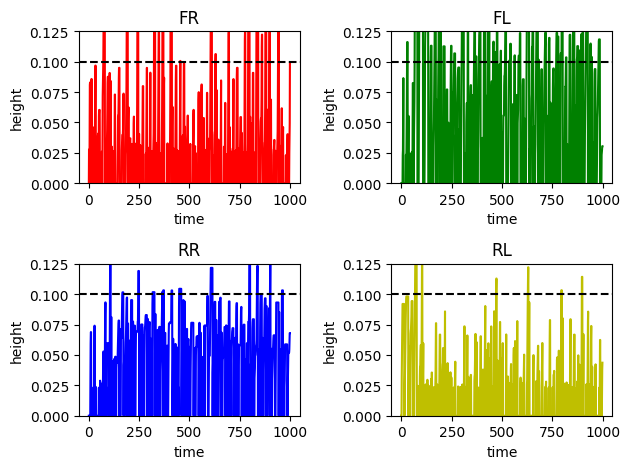

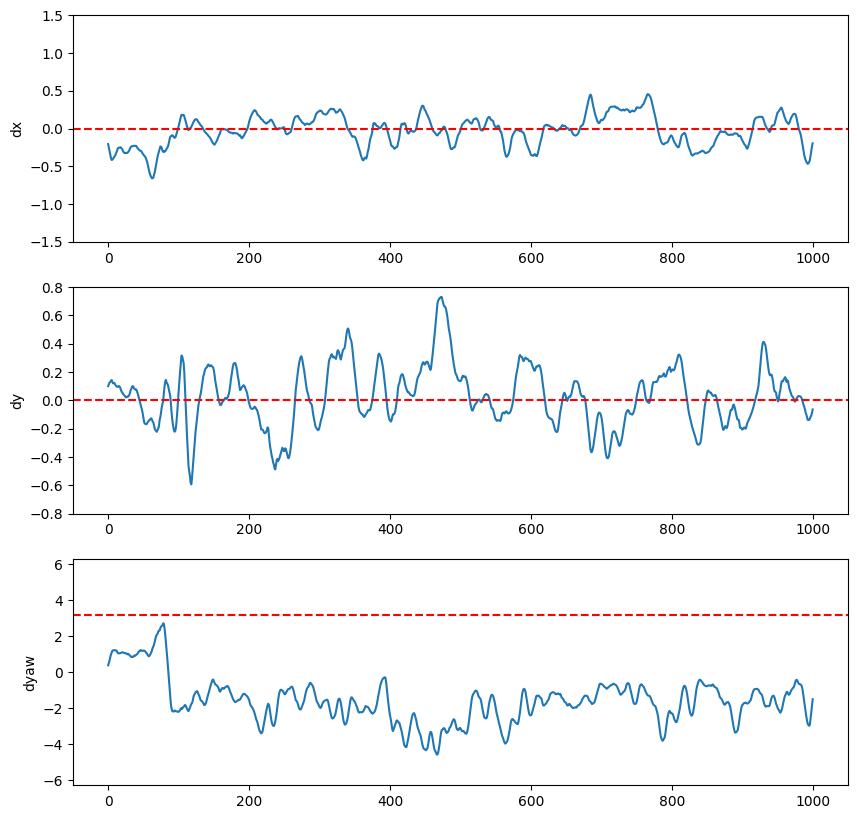

In [17]:
#@title Plot each foot in a 2x2 grid.

swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])

Now let's visualize what it looks like to slowly increase linear velocity commands.

Setting x to 0.0
Setting x to 0.25
Setting x to 0.5
Setting x to 0.75
Setting x to 1.0
Setting x to 1.25
Setting x to 1.5


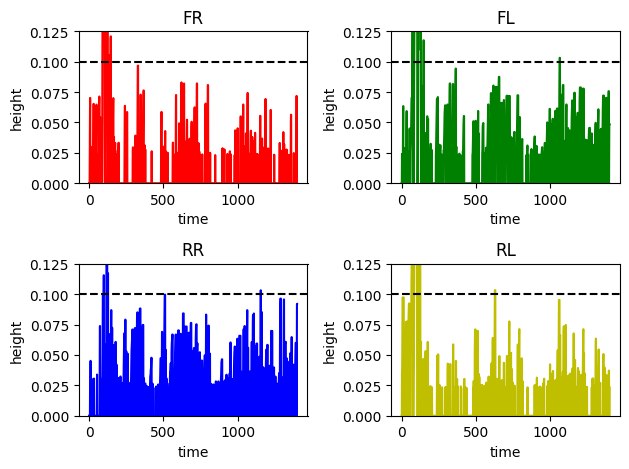

fps: 25.0


100%|██████████| 700/700 [00:05<00:00, 136.53it/s]


This browser does not support the video tag.


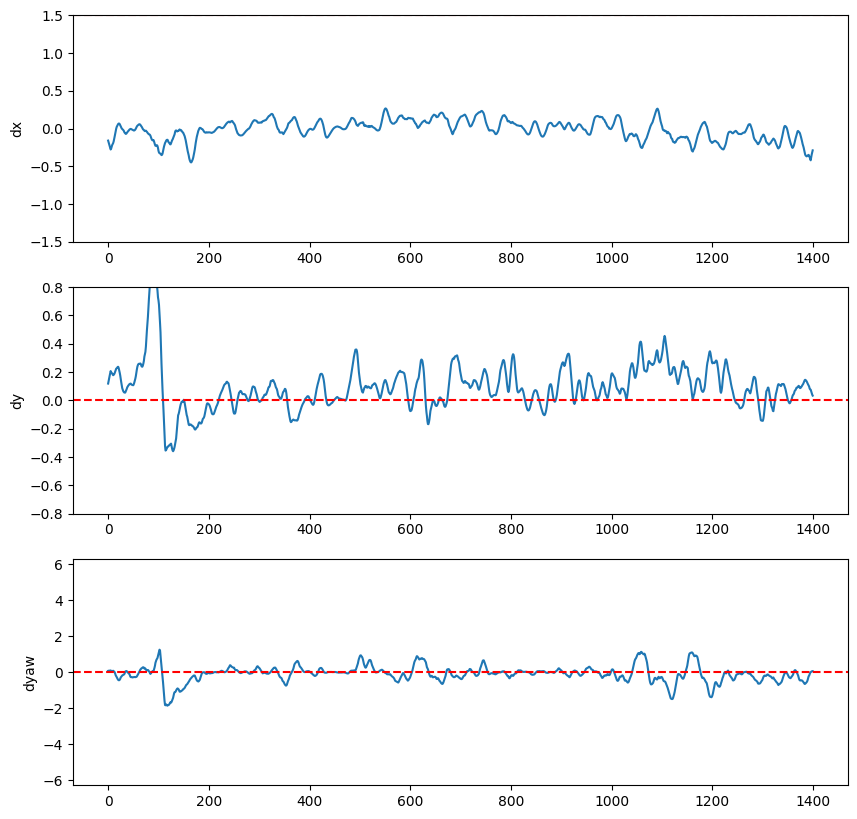

In [18]:
#@title Slowly increase linvel commands

rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []
swing_peak = []
linvel = []
angvel = []

x = -0.25
command = jp.array([x, 0, 0])
state = jit_reset(rng)
for i in range(1_400):
  # Increase the forward velocity by 0.25 m/s every 200 steps.
  if i % 200 == 0:
    x += 0.25
    print(f"Setting x to {x}")
    command = jp.array([x, 0, 0])
  state.info["command"] = command
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=command,
          xyz=xyz,
          theta=yaw,
          scl=abs(command[0]) / env_cfg.command_config.a[0],
      )
  )


# Plot each foot in a 2x2 grid.
swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])


render_every = 2
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")

traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]
assert len(traj) == len(mod_fns)

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    height=480,
    width=640,
    modify_scene_fns=mod_fns,
    scene_option=scene_option,
)
media.show_video(frames, fps=fps, loop=False)

🙌 Hasta la vista!